<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/fyp0_draft0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Import the data

In [120]:
df = pd.read_excel('/content/1-s2.0-S2352340922000026-mmc1.xlsx')
df.head()

,Department designation,ID,"family history (yes, no)","sex (f,m)",date of birth,"summer birth (yes, no)","winter birth (yes, no)","autumn birth (yes, no)","spring birth (yes, no)",age at admission (y.o.),...,g10,g11,g12,g13,g14,g15,g16,PANSS total (score),"Avolition/Asociality factor, score","Diminished Expression factor, score"
0,fam.0,125,no,m,03 10 1985,no,no,yes,no,12.0,...,3.0,5.0,6.0,4.0,1.0,1.0,4.0,80,14,25
1,sch,81,NaN,m,13 08 1987,yes,no,no,no,22.0,...,4.0,3.0,5.0,3.0,3.0,4.0,5.0,101,13,20
2,ep.97,333,no,m,1963,NaN,NaN,NaN,NaN,37.0,...,3.0,4.0,4.0,3.0,4.0,4.0,4.0,111,12,22
3,ep.97,1685,yes,f,02 06 1991,yes,no,no,no,19.0,...,1.0,4.0,4.0,5.0,1.0,2.0,4.0,95,12,22
4,sch,27,NaN,m,15 03 1983,no,no,no,yes,26.0,...,1.0,3.0,3.0,1.0,1.0,3.0,2.0,61,4,14


In [121]:
df = df.drop(columns = [col for col in df.columns if 'birth' in col])
df = df.drop(columns = ['ID'])

Renaming columns more descriptively

In [122]:
#7 questions and 7 LEVELS
pos_col_dict = {'p1': 'delusions',
                'p2': 'conceptual_disorganization',
                'p3': 'hallucinatory_behaviour',
                'p4': 'excitement',
                'p5': 'grandiosity',
                'p6': 'suspiciousness_persecution',
                'p7': 'hostility'}
df = df.rename(columns = pos_col_dict)

#also 7 questions and 7 levels
neg_col_dict = {'n1': 'blunted_affect',
                'n2': 'emotional_witdrawal',
                'n3': 'poor_rapport',
                'n4': 'social_withdrawal',
                'n5': 'difficult_abstract_thinking',
                'n6': 'lack_spontenaity',
                'n7': 'stereotyped_thinking'}
df = df.rename(columns= neg_col_dict)

#16 items also 7 levels
g_col_dict = {'g1': 'somatic_concern',
              'g2': 'anxiety',
              'g3': 'guilt_feelings',
              'g4': 'tension',
              'g5': 'mannerisms_posture',
              'g7': 'motor_retardation',
              'g8': 'uncooperativeness',
              'g9': 'unusual_thought_content',
              'g10': 'disorentation',
              'g11': 'poor_attention',
              'g12': 'lack_insight',
              'g13': 'volition_disturbance',
              'g14': 'poor_impulse_control',
              'g15': 'preoccupation',
              'g16': 'social_avoidance'}
df = df.rename(columns = g_col_dict)

#other renaming
rename_dict = {'Department designation': 'des',
               'family history (yes, no)': 'family_hist',
               'sex (f,m)': 'sex',
               'age at admission (y.o.)': 'admission_age',
               'age at onset (y.o.)': 'onset_age'}
df = df.rename(columns = rename_dict)
df.head()

,des,family_hist,sex,admission_age,onset_age,PANSS-Positive (score),delusions,conceptual_disorganization,hallucinatory_behaviour,excitement,...,disorentation,poor_attention,lack_insight,volition_disturbance,poor_impulse_control,preoccupation,social_avoidance,PANSS total (score),"Avolition/Asociality factor, score","Diminished Expression factor, score"
0,fam.0,no,m,12.0,3.0,NaN,NaN,NaN,NaN,NaN,...,3.0,5.0,6.0,4.0,1.0,1.0,4.0,80,14,25
1,sch,NaN,m,22.0,4.0,25.0,5.0,5.0,5.0,3.0,...,4.0,3.0,5.0,3.0,3.0,4.0,5.0,101,13,20
2,ep.97,no,m,37.0,4.0,26.0,4.0,3.0,3.0,4.0,...,3.0,4.0,4.0,3.0,4.0,4.0,4.0,111,12,22
3,ep.97,yes,f,19.0,4.0,25.0,4.0,5.0,3.0,5.0,...,1.0,4.0,4.0,5.0,1.0,2.0,4.0,95,12,22
4,sch,NaN,m,26.0,5.0,17.0,5.0,1.0,3.0,3.0,...,1.0,3.0,3.0,1.0,1.0,3.0,2.0,61,4,14


In [123]:
df.columns

Index(['des', 'family_hist', 'sex', 'admission_age', 'onset_age',
       'PANSS-Positive (score)', 'delusions', 'conceptual_disorganization',
       'hallucinatory_behaviour', 'excitement', 'grandiosity',
       'suspiciousness_persecution', 'hostility', 'PANSS-Negative (score)',
       'blunted_affect', 'emotional_witdrawal', 'poor_rapport',
       'social_withdrawal', 'difficult_abstract_thinking', 'lack_spontenaity',
       'stereotyped_thinking', 'PANSS-General psychopathology (score)',
       'somatic_concern', 'anxiety', 'guilt_feelings', 'tension',
       'mannerisms_posture', 'g6', 'motor_retardation', 'uncooperativeness',
       'unusual_thought_content', 'disorentation', 'poor_attention',
       'lack_insight', 'volition_disturbance', 'poor_impulse_control',
       'preoccupation', 'social_avoidance', 'PANSS total (score)',
       'Avolition/Asociality factor, score ',
       'Diminished Expression factor, score'],
      dtype='object')

Missingness

In [124]:
missingness_counts = list(df.isnull().sum().items())

high_missingness_index = []
for num in range(len(df.columns)):
  if missingness_counts[num][1] > 100:
    high_missingness_index.append(num)

high_missingness_df = df.iloc[:, high_missingness_index]
high_missingness_df = pd.concat([high_missingness_df, df['PANSS total (score)']], axis=1)

Missingness Plot

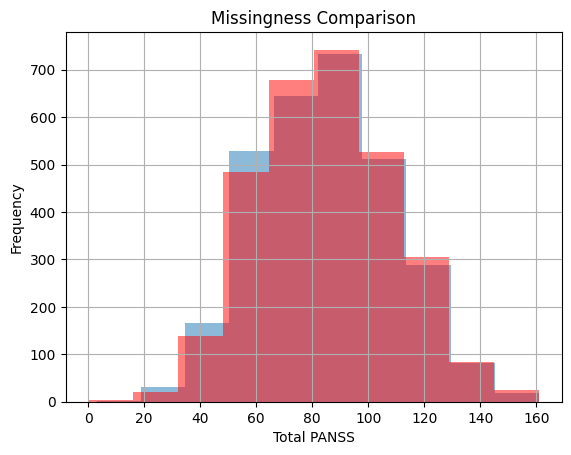

In [125]:
df['PANSS total (score)'] = pd.to_numeric(df['PANSS total (score)'], errors='coerce')
high_missingness_df['PANSS total (score)'] = pd.to_numeric(high_missingness_df['PANSS total (score)'], errors='coerce')
high_missingness_df['PANSS total (score)'] = high_missingness_df['PANSS total (score)'].fillna(0)

plt.title('Missingness Comparison')
plt.ylabel('Frequency')
plt.xlabel('Total PANSS')
df['PANSS total (score)'].hist(alpha = 0.5)
high_missingness_df['PANSS total (score)'].hist(alpha = 0.5, color = 'red')
#add legend
plt.show()

Numeric test: Little's MCAR

Deal with missingness later via KNN imputation in pipeline

EDA

<Axes: >

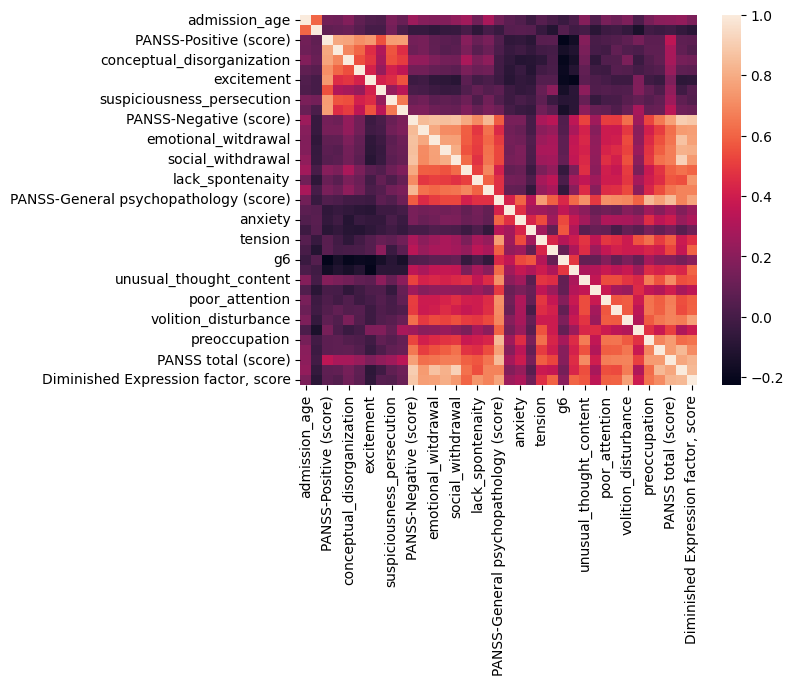

In [126]:
sns.heatmap(df.select_dtypes(include = ['number']).corr())

Incorporate Factor analysis??? For now use Lasso in preprocessing or later (after testing) drop redundant columns. Lasso over PCA for now for max interpretability. Use SelectFromModel wrapper.

Preprocessing

In [135]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.linear_model import Ridge, RidgeCV, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

Perhaps a plot with Lasso coefficients, extracted from the pipeline.

In [128]:
#drop columns with subscores (AI reordered)
panss_total_score_col = df['PANSS total (score)']

subscores_list = [col for col in df.columns if 'score' in col]

df = df.drop(columns = subscores_list)
df = pd.concat([df, panss_total_score_col], axis = 1)

Training test and numerical categorical split

In [133]:
X = df.drop(columns = ['PANSS total (score)'])
y = df['PANSS total (score)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

num_cols_list = list(X.select_dtypes(include = ['number']))
cat_cols_list = list(X.select_dtypes(include = ['object']))

Build pipeline: KNN imputer requires K. Use GridSearch to find optimal k.

In [136]:
num_pipe = Pipeline(steps = [
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

cat_pipe = Pipeline(steps = [
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

Join side by side with column transformer